In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


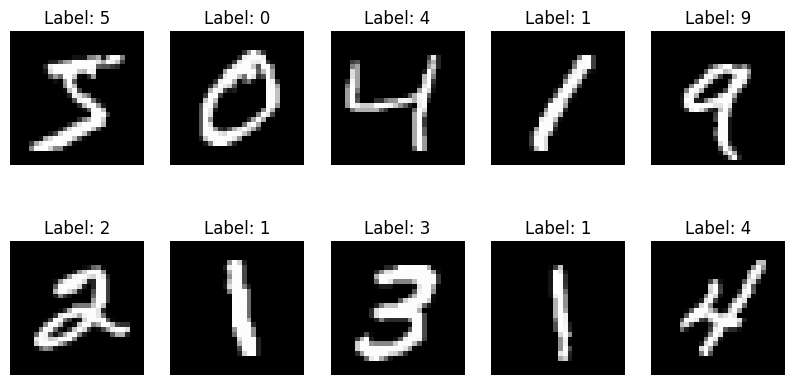

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

In [4]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("After preprocessing:")
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

After preprocessing:
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [5]:
model = models.Sequential([

    # Convolution layer
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(28, 28, 1)),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Second pooling layer
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into 1D
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Output layer - 10 digits
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9505 - loss: 0.1652 - val_accuracy: 0.9843 - val_loss: 0.0507
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9849 - loss: 0.0478 - val_accuracy: 0.9878 - val_loss: 0.0401
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9892 - val_loss: 0.0357
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9900 - val_loss: 0.0347
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 0.9877 - val_loss: 0.0437
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0.9913 - val_loss: 0.0330
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 0.9918 - val_loss: 0.0321
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9969 - loss: 0.0093 - val_accuracy: 0

In [8]:
epochs=5

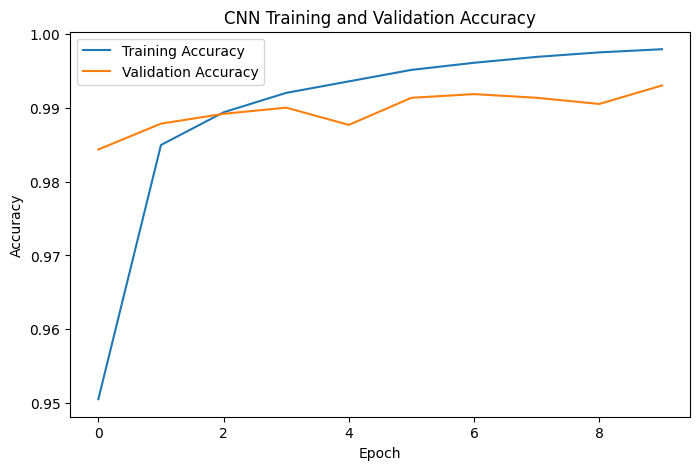

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()
plt.show()

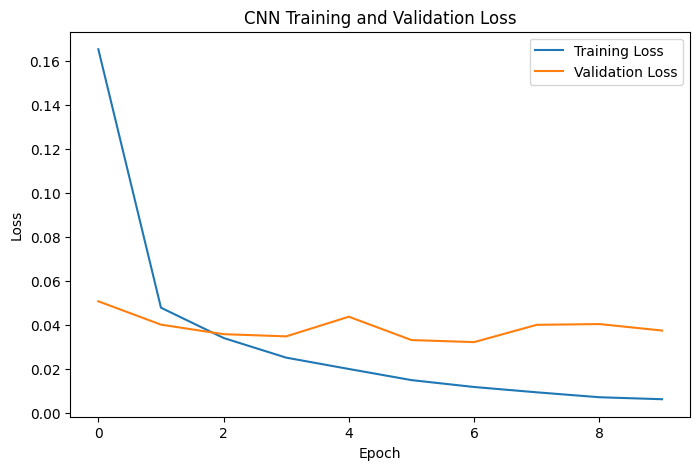

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()
plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9919 - loss: 0.0334
Test Loss: 0.03335191681981087
Test Accuracy: 0.9919000267982483


In [12]:
predictions = model.predict(x_test)

# Get predicted class
predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels:   ", y_test[:10])
print("Predicted labels:", predicted_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual labels:    [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 5 9]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step


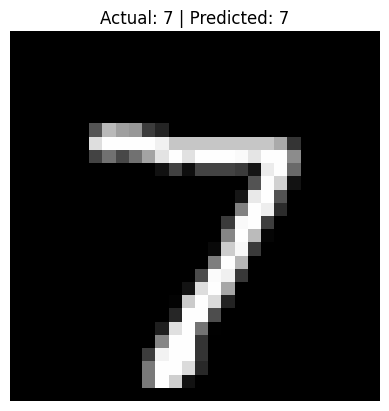

In [13]:
index = 0

plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
plt.axis('off')

prediction = np.argmax(model.predict(x_test[index:index+1]))

plt.title(
    "Actual: " + str(y_test[index]) +
    " | Predicted: " + str(prediction)
)

plt.show()

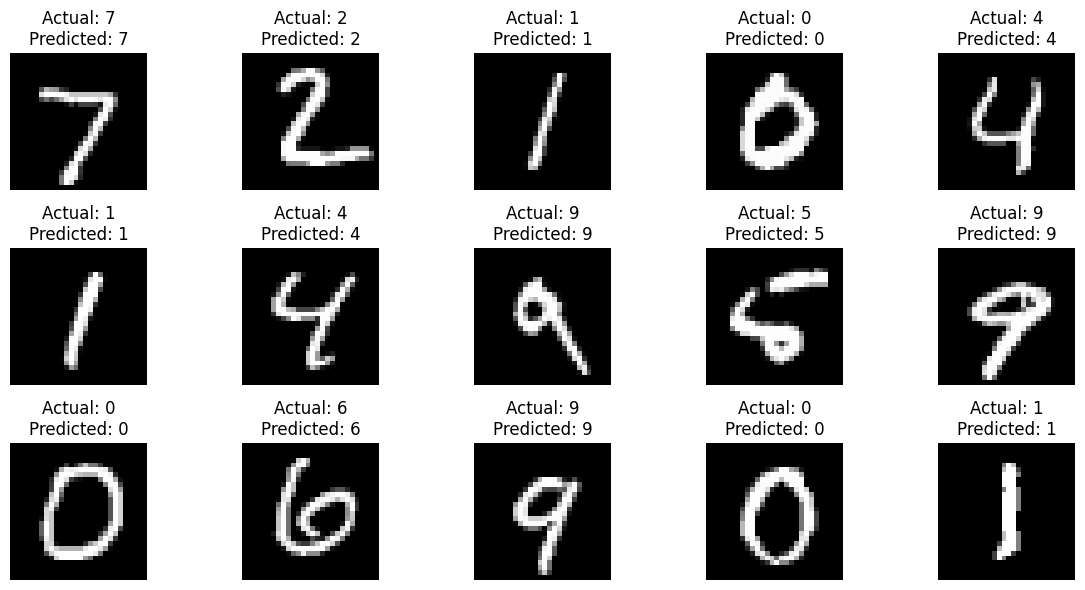

In [14]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    predicted = predicted_labels[i]
    actual = y_test[i]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

Saving mnist.webp to mnist.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


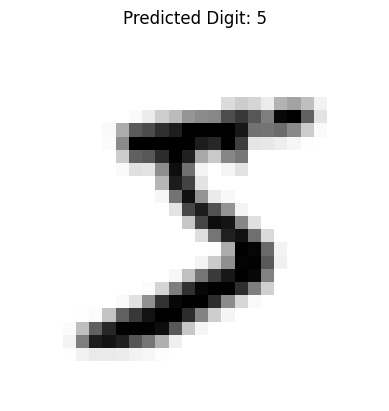

Predicted digit: 5


In [15]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Open image
img = Image.open(filename).convert('L')

# Resize
img = img.resize((28, 28))

# Convert to numpy
img_array = np.array(img)

# Invert image
img_array = 255 - img_array

# Normalize
img_array = img_array.astype('float32') / 255.0

# Reshape
img_array = img_array.reshape(1, 28, 28, 1)

# Predict
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

# Display
plt.imshow(img_array[0, :, :, 0], cmap='gray')
plt.axis('off')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.show()

print("Predicted digit:", predicted_digit)